Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


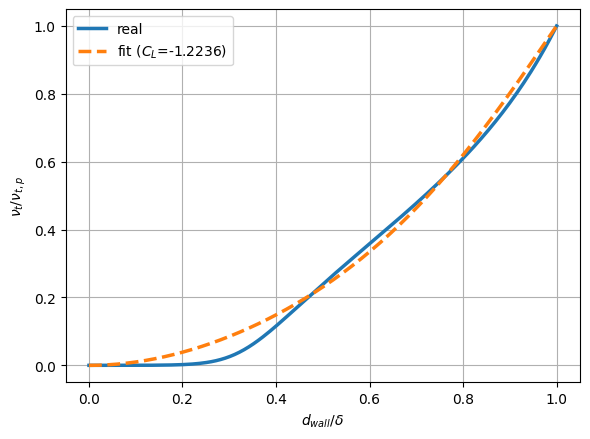

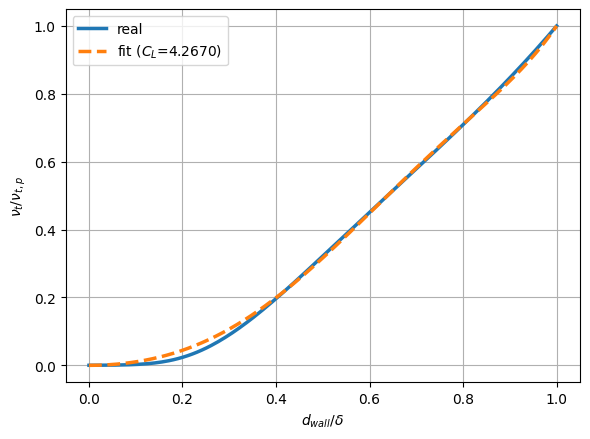

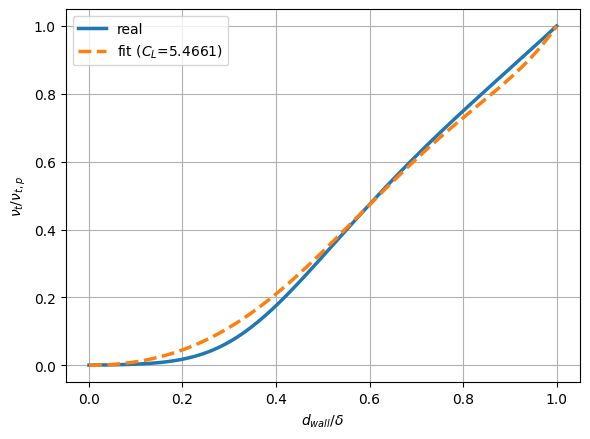

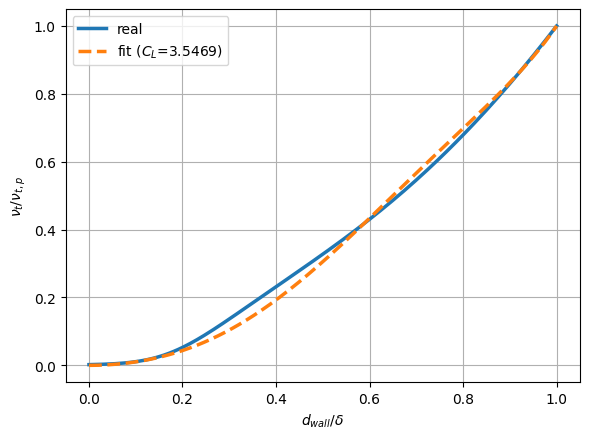

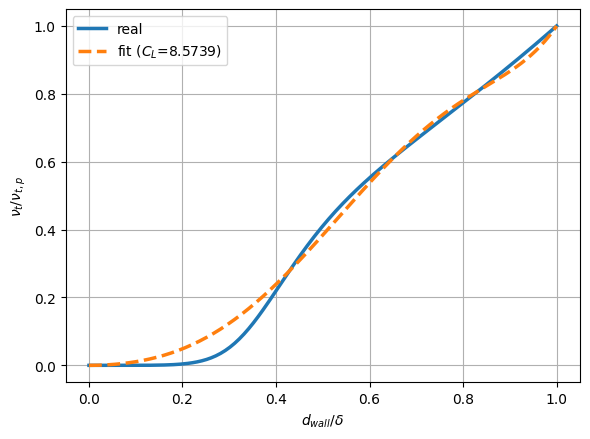

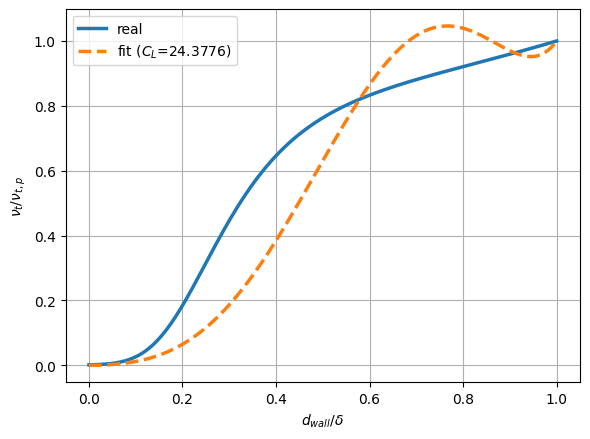

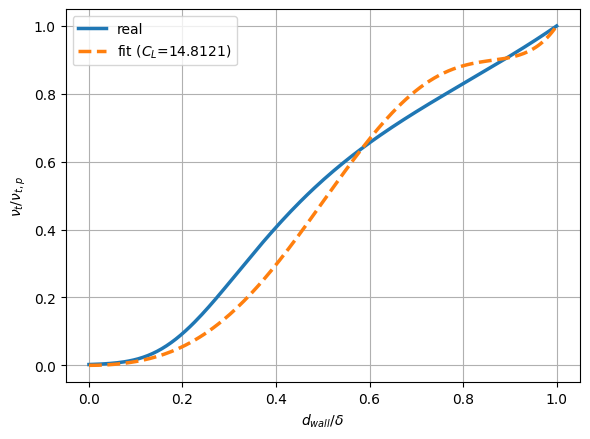

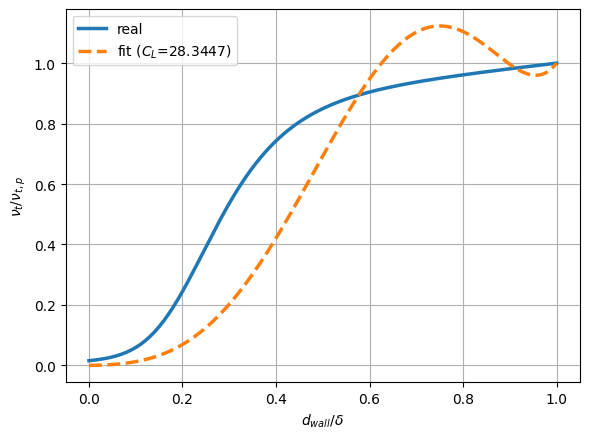


Fitted A values for liquid phase:
   case_id          A      rmse        r2  n_points
0        0  -1.223638  0.027954  0.991459       200
1        1   4.267040  0.009661  0.999082       200
2        2   5.466087  0.023138  0.995218       200
3        3   3.546902  0.019830  0.995645       200
4        4   8.573882  0.030102  0.992397       200
5        5  24.377611  0.141766  0.829669       200
6        6  14.812065  0.057989  0.969018       200
7        7  28.344684  0.179216  0.730426       200

Saved fit summary to: /content/drive/MyDrive/liquid_A_per_case_sqeta_model.csv


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Load liquid dataset
# ============================================================
LIQUID_CSV = '/content/drive/MyDrive/liquid_dataset_geometry_nut_norm.csv'
df_liquid = pd.read_csv(LIQUID_CSV)

# Optional: exclude cases if desired
# df_liquid = df_liquid[~df_liquid['case_id'].isin([0, 4])].copy()

# ============================================================
# Model:
# nut/nut_p = x^2 * [1 + A*(x*(1-x))^2]
# where x = d_wall/delta
# ============================================================
def liquid_model(x, A):
    eta = x * (1.0 - x)
    return x**2 * (1.0 + A * eta**2)

# ============================================================
# Fit A separately for each case
# ============================================================
fit_rows = []

case_ids = sorted(df_liquid['case_id'].unique())

for case_id in case_ids:
    dfc = df_liquid[df_liquid['case_id'] == case_id].copy()

    x = dfc['d_wall_delta'].values
    y = dfc['nut_over_nut_p'].values

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 5:
        print(f"Case {case_id}: skipped (not enough valid points)")
        continue

    # A can be positive or negative
    p0 = [0.0]
    bounds = ([-1000.0], [1000.0])

    try:
        popt, pcov = curve_fit(
            liquid_model,
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        A = popt[0]
        y_fit = liquid_model(x, A)

        mse = np.mean((y - y_fit)**2)
        rmse = np.sqrt(mse)
        ss_res = np.sum((y - y_fit)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        fit_rows.append({
            'case_id': case_id,
            'A': A,
            'rmse': rmse,
            'r2': r2,
            'n_points': len(x),
        })

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------
        idx = np.argsort(x)
        xs = x[idx]
        ys = y[idx]
        ys_fit = y_fit[idx]

        plt.figure(figsize=(6, 4.5))
        plt.plot(xs, ys, linewidth=2.5, label='real')
        plt.plot(xs, ys_fit, '--', linewidth=2.5, label=f"fit ($C_L$={A:.4f})")
        plt.xlabel(r'$d_{wall}/\delta$')
        plt.ylabel(r'$\nu_t/\nu_{t,p}$')
        # plt.title(f'Liquid phase - case {case_id+1}')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Case {case_id}: fit failed -> {e}")

# ============================================================
# Summary table
# ============================================================
df_A = pd.DataFrame(fit_rows).sort_values('case_id').reset_index(drop=True)

print("\nFitted A values for liquid phase:")
print(df_A)

OUT_FIT_CSV = '/content/drive/MyDrive/liquid_A_per_case_sqeta_model.csv'
df_A.to_csv(OUT_FIT_CSV, index=False)
print(f"\nSaved fit summary to: {OUT_FIT_CSV}")

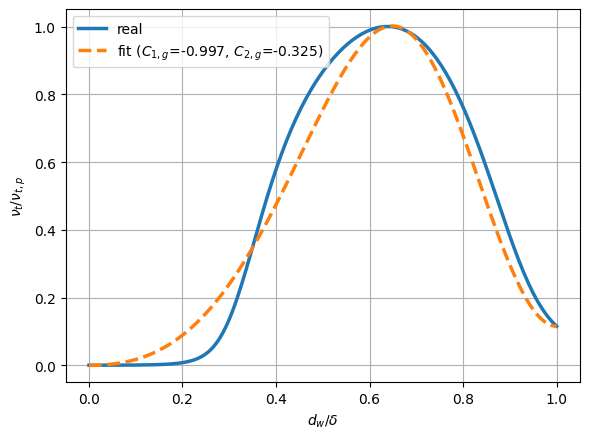

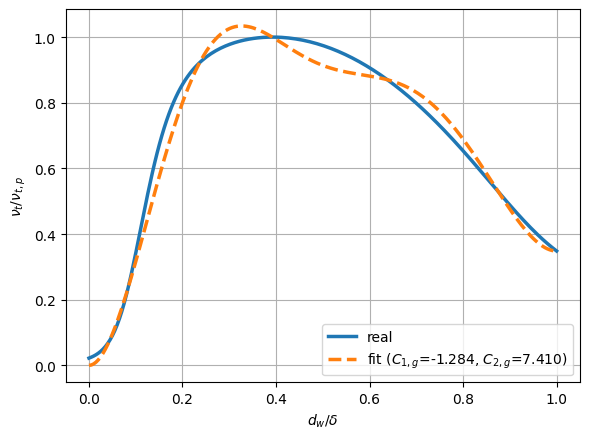

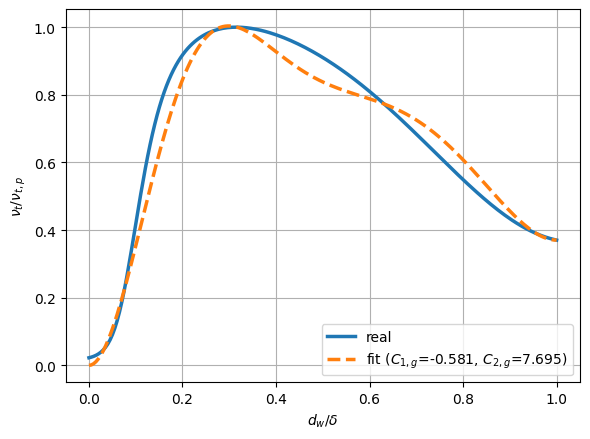

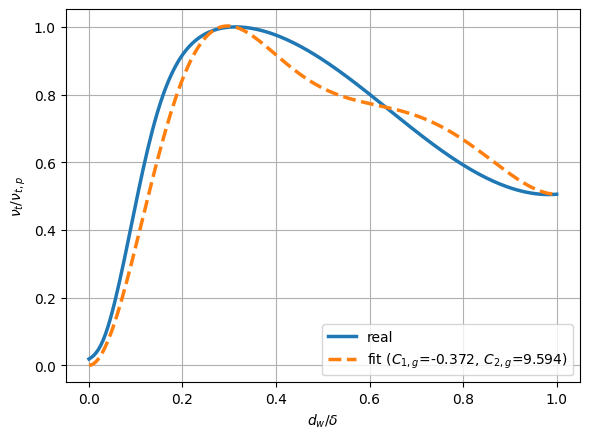

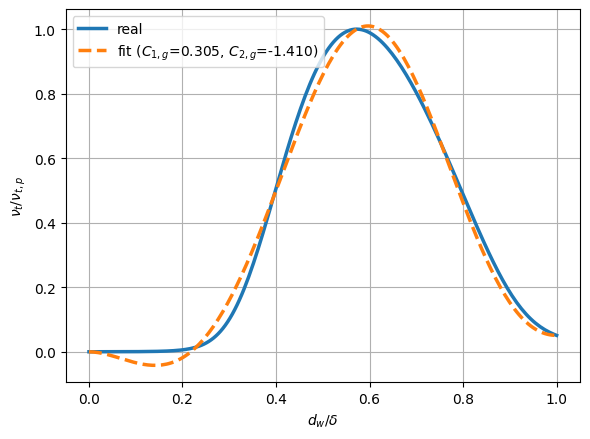

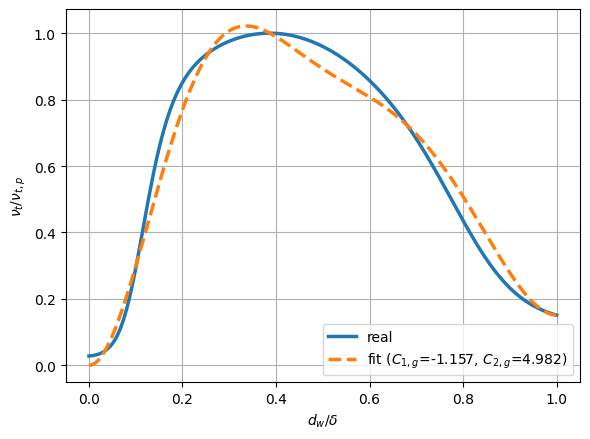

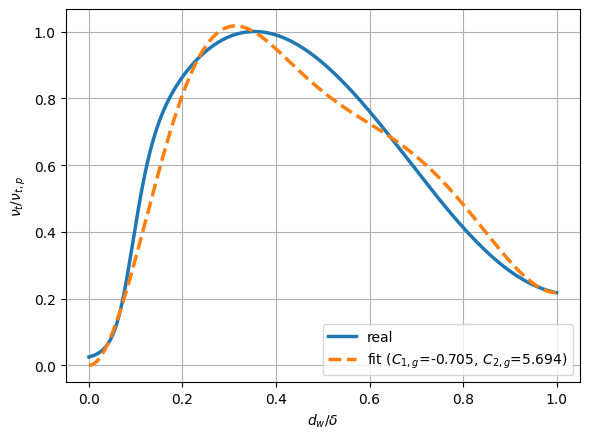

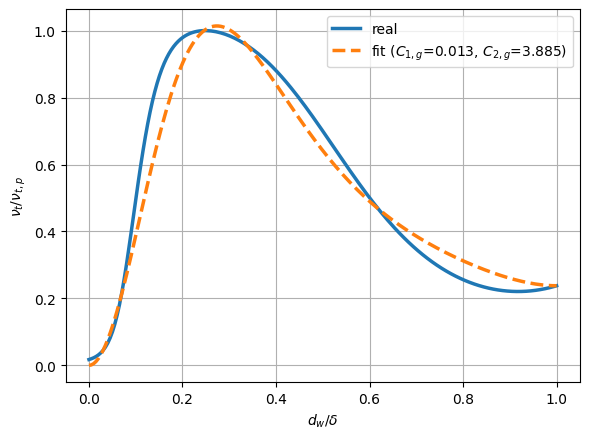


Fitted C1, C2 for gas phase:
   case_id        C1        C2      rmse        r2  n_points
0        0 -0.997392 -0.324536  0.073648  0.963612       200
1        1 -1.284342  7.409584  0.039493  0.980309       200
2        2 -0.580743  7.695126  0.052939  0.963150       200
3        3 -0.371605  9.593962  0.064858  0.931612       200
4        4  0.304577 -1.409994  0.033538  0.991848       200
5        5 -1.157426  4.982226  0.050191  0.976811       200
6        6 -0.705216  5.693977  0.059577  0.961473       200
7        7  0.013365  3.884681  0.060382  0.962759       200

Saved summary to: /content/drive/MyDrive/gas_C1_C2_fit_summary.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Load gas dataset
# ============================================================
GAS_CSV = '/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv'
df_gas = pd.read_csv(GAS_CSV)

# Optional
# df_gas = df_gas[~df_gas['case_id'].isin([0, 4])].copy()

# ============================================================
# Model:
# y = (1-alpha)*A + alpha*B
#
# x  = dw/delta
# xp = dw_p/delta
# rI = nut_interface/nut_p
#
# A = (x/xp)^2 * [1 + C1 * x*(xp-x)/xp^2]
#
# B = rI + (1-rI) * ((1-x)/(1-xp))^2 *
#           [1 + C2 * (xp-x)*(1-x)/(1-xp)^2]
#
# alpha = x^2 / [x^2 + xp^2 * ((1-x)/(1-xp))^2]
# ============================================================
def gas_model_C1C2(X, C1, C2):
    eps = 1e-12

    x = X[:, 0]
    xp = X[:, 1]
    nut_interface = X[:, 2]
    nut_p = X[:, 3]

    xp_safe = np.maximum(xp, eps)
    one_minus_xp_safe = np.maximum(1.0 - xp, eps)

    rI = nut_interface / np.maximum(nut_p, eps)

    # --------------------------------------------------------
    # A branch
    # --------------------------------------------------------
    A = (x / xp_safe)**2 * (
        1.0 + C1 * x * (xp - x) / (xp_safe**2)
    )

    # --------------------------------------------------------
    # B branch
    # --------------------------------------------------------
    ratio_int = (1.0 - x) / one_minus_xp_safe
    B = rI + (1.0 - rI) * (ratio_int**2) * (
        1.0 + C2 * (xp - x) * (1.0 - x) / (one_minus_xp_safe**2)
    )

    # --------------------------------------------------------
    # alpha
    # --------------------------------------------------------
    denom = x**2 + xp**2 * (ratio_int**2)
    alpha = x**2 / np.maximum(denom, eps)

    # --------------------------------------------------------
    # final model
    # --------------------------------------------------------
    y = (1.0 - alpha) * A + alpha * B
    return y

# ============================================================
# Fit case by case
# ============================================================
rows = []

for case_id in sorted(df_gas['case_id'].unique()):
    dfc = df_gas[df_gas['case_id'] == case_id].copy()

    X_case = dfc[
        ['d_wall_delta', 'd_wall_p_delta', 'nut_interface', 'nut_p']
    ].values
    y_true = dfc['nut_over_nut_p'].values

    mask = np.all(np.isfinite(X_case), axis=1) & np.isfinite(y_true)
    X_case = X_case[mask]
    y_true = y_true[mask]
    dfc = dfc.loc[mask].copy()

    if len(y_true) < 5:
        print(f"Case {case_id}: skipped")
        continue

    try:
        popt, _ = curve_fit(
            gas_model_C1C2,
            X_case,
            y_true,
            p0=[0.0, 0.0],
            bounds=([-100.0, -100.0], [100.0, 100.0]),
            maxfev=50000
        )

        C1_opt, C2_opt = popt
        y_fit = gas_model_C1C2(X_case, C1_opt, C2_opt)

        mse = np.mean((y_true - y_fit)**2)
        rmse = np.sqrt(mse)
        ss_res = np.sum((y_true - y_fit)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        rows.append({
            'case_id': case_id,
            'C1': C1_opt,
            'C2': C2_opt,
            'rmse': rmse,
            'r2': r2,
            'n_points': len(y_true),
        })

        # ----------------------------------------------------
        # plot only real and fit
        # ----------------------------------------------------
        xplot = dfc['d_wall_delta'].values
        idx = np.argsort(xplot)

        plt.figure(figsize=(6, 4.5))
        plt.plot(xplot[idx], y_true[idx], linewidth=2.5, label='real')
        plt.plot(xplot[idx], y_fit[idx], '--', linewidth=2.5, label=f"fit ($C_{{1,g}}$={C1_opt:.3f}, $C_{{2,g}}$={C2_opt:.3f})")
        plt.xlabel(r'$d_w/\delta$')
        plt.ylabel(r'$\nu_t/\nu_{t,p}$')
        # plt.title(f'Gas phase - case {case_id+1}')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Case {case_id}: fit failed -> {e}")

# ============================================================
# Summary
# ============================================================
df_fit = pd.DataFrame(rows).sort_values('case_id').reset_index(drop=True)

print("\nFitted C1, C2 for gas phase:")
print(df_fit)

OUT_CSV = '/content/drive/MyDrive/gas_C1_C2_fit_summary.csv'
df_fit.to_csv(OUT_CSV, index=False)
print(f"\nSaved summary to: {OUT_CSV}")

In [ ]:
Re_L = np.array([3450.3535531, 3604.56651513, 3650.38144777, 3744.77563182,
                 4791.70675035, 5137.32386263, 5192.2847177, 5310.30353933])

Re_g = np.array([2444.18629244, 5714.13581516, 6692.97239, 9963.29544459,
                 2535.15810329, 5819.1523274, 6813.96014038, 10133.83525732])

dPdX_L = np.array([-0.00067507, -0.00187867, -0.00228591, -0.00348701,
                   -0.00079928, -0.00172978, -0.00205301, -0.00303126])

dPdX_g = np.array([-0.03091919, -0.02548305, -0.02586579, -0.02327339,
                   -0.03050943, -0.02891136, -0.02823237, -0.02418915])

Final training fit, excluding case 1 and case 5
A = 0.011744 * Re_L + -38.672110

Training metrics on included cases:
R²    = 0.846677
RMSE  = 3.878944
MAE   = 3.084964

LOOCV metrics on included cases:
R²    = 0.653008
RMSE  = 5.835383
MAE   = 4.636755

Saved files:
A_vs_ReL_fit_summary.csv
A_vs_ReL_LOOCV_details.csv


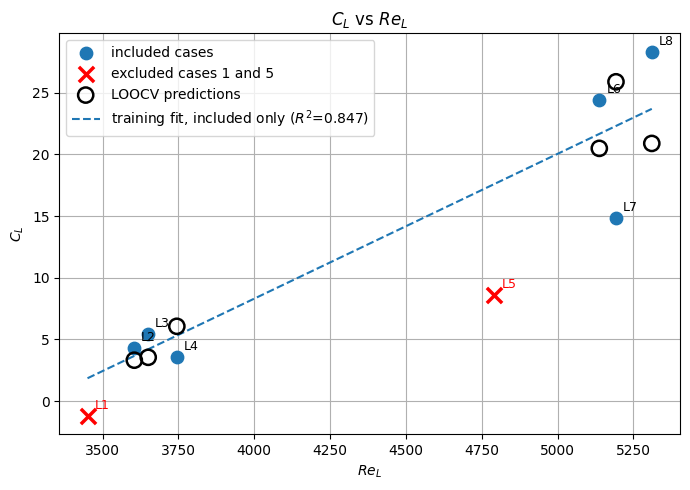

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# Input data
# ============================================================

Re_L = np.array([
    3450.3535531, 3604.56651513, 3650.38144777, 3744.77563182,
    4791.70675035, 5137.32386263, 5192.2847177, 5310.30353933
])

A_vals = np.array([
    -1.22, 4.28, 5.47, 3.55,
    8.57, 24.38, 14.81, 28.34
])

case_labels = np.arange(1, 9)

# ============================================================
# Exclude case 1 and case 5 from fitting
# ============================================================

excluded_cases = np.array([1, 5])
included_mask = ~np.isin(case_labels, excluded_cases)
excluded_mask = np.isin(case_labels, excluded_cases)

Re_L_fit = Re_L[included_mask]
A_fit = A_vals[included_mask]
case_fit = case_labels[included_mask]

Re_L_excluded = Re_L[excluded_mask]
A_excluded = A_vals[excluded_mask]
case_excluded = case_labels[excluded_mask]

# ============================================================
# Training fit on included cases only
# ============================================================

m, b = np.polyfit(Re_L_fit, A_fit, 1)

xfit = np.linspace(Re_L.min(), Re_L.max(), 200)
yfit = m * xfit + b

# predictions on included training cases
A_train_pred = m * Re_L_fit + b

# training metrics
train_r2 = r2_score(A_fit, A_train_pred)
train_rmse = np.sqrt(mean_squared_error(A_fit, A_train_pred))
train_mae = mean_absolute_error(A_fit, A_train_pred)

# ============================================================
# LOOCV only on included cases
# ============================================================

loocv_pred = np.zeros_like(A_fit, dtype=float)
loocv_m = np.zeros_like(A_fit, dtype=float)
loocv_b = np.zeros_like(A_fit, dtype=float)

for i in range(len(Re_L_fit)):
    train_mask = np.ones(len(Re_L_fit), dtype=bool)
    train_mask[i] = False

    Re_train = Re_L_fit[train_mask]
    A_train = A_fit[train_mask]

    m_i, b_i = np.polyfit(Re_train, A_train, 1)

    loocv_m[i] = m_i
    loocv_b[i] = b_i
    loocv_pred[i] = m_i * Re_L_fit[i] + b_i

# LOOCV metrics
loocv_r2 = r2_score(A_fit, loocv_pred)
loocv_rmse = np.sqrt(mean_squared_error(A_fit, loocv_pred))
loocv_mae = mean_absolute_error(A_fit, loocv_pred)

# ============================================================
# Print results
# ============================================================

print("============================================================")
print("Final training fit, excluding case 1 and case 5")
print("============================================================")
print(f"A = {m:.6f} * Re_L + {b:.6f}")
print()
print("Training metrics on included cases:")
print(f"R²    = {train_r2:.6f}")
print(f"RMSE  = {train_rmse:.6f}")
print(f"MAE   = {train_mae:.6f}")
print()
print("LOOCV metrics on included cases:")
print(f"R²    = {loocv_r2:.6f}")
print(f"RMSE  = {loocv_rmse:.6f}")
print(f"MAE   = {loocv_mae:.6f}")

# ============================================================
# Save summary and LOOCV details
# ============================================================

summary_df = pd.DataFrame({
    "model": ["A = m * Re_L + b"],
    "excluded_cases": [", ".join(map(str, excluded_cases))],
    "included_cases": [", ".join(map(str, case_fit))],
    "m": [m],
    "b": [b],
    "training_R2": [train_r2],
    "training_RMSE": [train_rmse],
    "training_MAE": [train_mae],
    "LOOCV_R2": [loocv_r2],
    "LOOCV_RMSE": [loocv_rmse],
    "LOOCV_MAE": [loocv_mae]
})

loocv_details_df = pd.DataFrame({
    "case": case_fit,
    "Re_L": Re_L_fit,
    "A_true": A_fit,
    "A_train_fit_pred": A_train_pred,
    "A_LOOCV_pred": loocv_pred,
    "LOOCV_error": A_fit - loocv_pred,
    "LOOCV_abs_error": np.abs(A_fit - loocv_pred),
    "LOOCV_m": loocv_m,
    "LOOCV_b": loocv_b
})

summary_df.to_csv("A_vs_ReL_fit_summary.csv", index=False)
loocv_details_df.to_csv("A_vs_ReL_LOOCV_details.csv", index=False)

print()
print("Saved files:")
print("A_vs_ReL_fit_summary.csv")
print("A_vs_ReL_LOOCV_details.csv")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

# included cases
plt.scatter(
    Re_L_fit,
    A_fit,
    s=80,
    label="included cases",
    zorder=3
)

# excluded cases: red crosses
plt.scatter(
    Re_L_excluded,
    A_excluded,
    s=120,
    marker="x",
    color="red",
    linewidths=2.5,
    label="excluded cases 1 and 5",
    zorder=4
)

# LOOCV predictions: hollow black circles
plt.scatter(
    Re_L_fit,
    loocv_pred,
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    label="LOOCV predictions",
    zorder=5
)

# final training fit
plt.plot(
    xfit,
    yfit,
    "--",
    label=fr"training fit, included only ($R^2$={train_r2:.3f})",
    zorder=2
)

# case labels for included cases
for i in range(len(Re_L_fit)):
    plt.annotate(
        f"L{case_fit[i]}",
        (Re_L_fit[i], A_fit[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

# case labels for excluded cases
for i in range(len(Re_L_excluded)):
    plt.annotate(
        f"L{case_excluded[i]}",
        (Re_L_excluded[i], A_excluded[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        color="red"
    )

plt.xlabel(r"$Re_L$")
plt.ylabel(r"$C_L$")
plt.title(r"$C_L$ vs $Re_L$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gas phase fit, excluding case 1 and case 5
Fitted relation:
y = 0.207886 x + -0.056330

where:
x = Re_g / Re_L
y = nut_interface / nut_p

Included cases:
[2 3 4 6 7 8]

Excluded cases:
[1 5]

Training metrics on included cases:
R²    = 0.767693
RMSE  = 0.056415
MAE   = 0.043497

LOOCV metrics on included cases:
R²    = 0.624033
RMSE  = 0.071769
MAE   = 0.059583

Saved files:
/content/drive/MyDrive/gas_phase_fit_summary.csv
/content/drive/MyDrive/gas_phase_LOOCV_details.csv


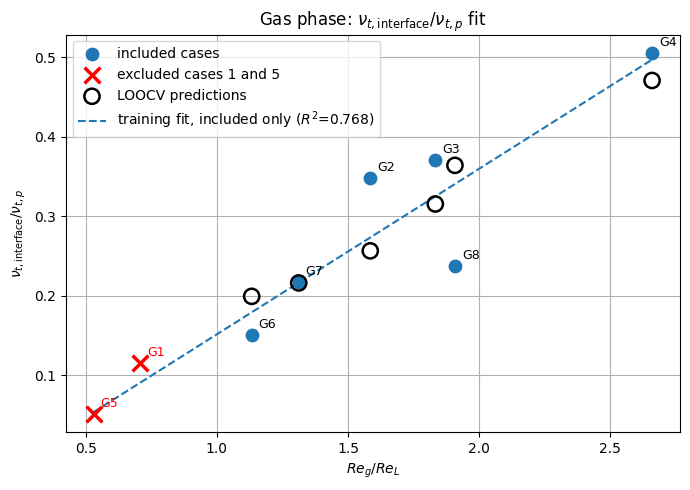

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# Reynolds numbers
# ============================================================

Re_L = np.array([
    3450.3535531, 3604.56651513, 3650.38144777, 3744.77563182,
    4791.70675035, 5137.32386263, 5192.2847177, 5310.30353933
])

Re_g = np.array([
    2444.18629244, 5714.13581516, 6692.97239, 9963.29544459,
    2535.15810329, 5819.1523274, 6813.96014038, 10133.83525732
])

# ============================================================
# Load gas dataset
# ============================================================

GAS_CSV = "/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv"
df_gas = pd.read_csv(GAS_CSV)

# ============================================================
# One row per case
# ============================================================

df_gas_case = (
    df_gas.groupby("case_id", as_index=False)
    .first()[["case_id", "nut_interface", "nut_p"]]
)

# case_id is assumed to be 0-based: 0,...,7
df_gas_case["case_number"] = df_gas_case["case_id"] + 1

# add Reynolds numbers
df_gas_case["Re_g"] = df_gas_case["case_id"].map(lambda i: Re_g[int(i)])
df_gas_case["Re_L"] = df_gas_case["case_id"].map(lambda i: Re_L[int(i)])

# variables
df_gas_case["xvar"] = df_gas_case["Re_g"] / df_gas_case["Re_L"]
df_gas_case["yvar"] = df_gas_case["nut_interface"] / df_gas_case["nut_p"]

# ============================================================
# Exclude case 1 and case 5 from fitting
# ============================================================

excluded_cases = np.array([1, 5])

included_mask = ~df_gas_case["case_number"].isin(excluded_cases)
excluded_mask = df_gas_case["case_number"].isin(excluded_cases)

df_fit = df_gas_case[included_mask].copy()
df_excluded = df_gas_case[excluded_mask].copy()

x_fit_data = df_fit["xvar"].values
y_fit_data = df_fit["yvar"].values

x_excluded = df_excluded["xvar"].values
y_excluded = df_excluded["yvar"].values

# ============================================================
# Training fit on included cases only
# y = m*x + b
# ============================================================

m, b = np.polyfit(x_fit_data, y_fit_data, 1)

y_train_pred = m * x_fit_data + b

train_r2 = r2_score(y_fit_data, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_fit_data, y_train_pred))
train_mae = mean_absolute_error(y_fit_data, y_train_pred)

# smooth line over all x-range
x_line = np.linspace(
    df_gas_case["xvar"].min(),
    df_gas_case["xvar"].max(),
    200
)
y_line = m * x_line + b

# ============================================================
# LOOCV only on included cases
# ============================================================

loocv_pred = np.zeros_like(y_fit_data, dtype=float)
loocv_m = np.zeros_like(y_fit_data, dtype=float)
loocv_b = np.zeros_like(y_fit_data, dtype=float)

for i in range(len(x_fit_data)):
    loo_mask = np.ones(len(x_fit_data), dtype=bool)
    loo_mask[i] = False

    x_train_loo = x_fit_data[loo_mask]
    y_train_loo = y_fit_data[loo_mask]

    m_i, b_i = np.polyfit(x_train_loo, y_train_loo, 1)

    loocv_m[i] = m_i
    loocv_b[i] = b_i
    loocv_pred[i] = m_i * x_fit_data[i] + b_i

loocv_r2 = r2_score(y_fit_data, loocv_pred)
loocv_rmse = np.sqrt(mean_squared_error(y_fit_data, loocv_pred))
loocv_mae = mean_absolute_error(y_fit_data, loocv_pred)

# ============================================================
# Print results
# ============================================================

print("============================================================")
print("Gas phase fit, excluding case 1 and case 5")
print("============================================================")
print("Fitted relation:")
print(f"y = {m:.6f} x + {b:.6f}")
print()
print("where:")
print("x = Re_g / Re_L")
print("y = nut_interface / nut_p")
print()
print("Included cases:")
print(df_fit["case_number"].values)
print()
print("Excluded cases:")
print(df_excluded["case_number"].values)
print()
print("Training metrics on included cases:")
print(f"R²    = {train_r2:.6f}")
print(f"RMSE  = {train_rmse:.6f}")
print(f"MAE   = {train_mae:.6f}")
print()
print("LOOCV metrics on included cases:")
print(f"R²    = {loocv_r2:.6f}")
print(f"RMSE  = {loocv_rmse:.6f}")
print(f"MAE   = {loocv_mae:.6f}")

# ============================================================
# Save summary and LOOCV details
# ============================================================

summary_df = pd.DataFrame({
    "model": ["y = m*x + b"],
    "x_definition": ["Re_g / Re_L"],
    "y_definition": ["nut_interface / nut_p"],
    "excluded_cases": [", ".join(map(str, excluded_cases))],
    "included_cases": [", ".join(map(str, df_fit["case_number"].values))],
    "m": [m],
    "b": [b],
    "training_R2": [train_r2],
    "training_RMSE": [train_rmse],
    "training_MAE": [train_mae],
    "LOOCV_R2": [loocv_r2],
    "LOOCV_RMSE": [loocv_rmse],
    "LOOCV_MAE": [loocv_mae]
})

loocv_details_df = df_fit[[
    "case_id",
    "case_number",
    "Re_g",
    "Re_L",
    "nut_interface",
    "nut_p",
    "xvar",
    "yvar"
]].copy()

loocv_details_df["y_train_fit_pred"] = y_train_pred
loocv_details_df["y_LOOCV_pred"] = loocv_pred
loocv_details_df["LOOCV_error"] = y_fit_data - loocv_pred
loocv_details_df["LOOCV_abs_error"] = np.abs(y_fit_data - loocv_pred)
loocv_details_df["LOOCV_m"] = loocv_m
loocv_details_df["LOOCV_b"] = loocv_b

summary_path = "/content/drive/MyDrive/gas_phase_fit_summary.csv"
loocv_path = "/content/drive/MyDrive/gas_phase_LOOCV_details.csv"

summary_df.to_csv(summary_path, index=False)
loocv_details_df.to_csv(loocv_path, index=False)

print()
print("Saved files:")
print(summary_path)
print(loocv_path)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

# included cases
plt.scatter(
    df_fit["xvar"],
    df_fit["yvar"],
    s=80,
    label="included cases",
    zorder=3
)

# excluded cases: red crosses
plt.scatter(
    df_excluded["xvar"],
    df_excluded["yvar"],
    s=130,
    marker="x",
    color="red",
    linewidths=2.5,
    label="excluded cases 1 and 5",
    zorder=4
)

# LOOCV predictions: hollow black circles
plt.scatter(
    df_fit["xvar"],
    loocv_pred,
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    label="LOOCV predictions",
    zorder=5
)

# final training fit
plt.plot(
    x_line,
    y_line,
    "--",
    label=fr"training fit, included only ($R^2$={train_r2:.3f})",
    zorder=2
)

# labels for included cases
for _, row in df_fit.iterrows():
    plt.annotate(
        f"G{int(row['case_number'])}",
        (row["xvar"], row["yvar"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

# labels for excluded cases
for _, row in df_excluded.iterrows():
    plt.annotate(
        f"G{int(row['case_number'])}",
        (row["xvar"], row["yvar"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        color="red"
    )

plt.xlabel(r"$Re_g/Re_L$")
plt.ylabel(r"$\nu_{t,\mathrm{interface}}/\nu_{t,p}$")
plt.title(
    r"Gas phase: $\nu_{t,\mathrm{interface}}/\nu_{t,p}$ fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Gas phase fit, excluding case 1 and case 5

Data table:
   case_number  case_id          Re_g         Re_L  nut_interface     nut_p  \
0            1        0   2444.186292  3450.353553       0.001632  0.014135   
1            2        1   5714.135815  3604.566515       0.001887  0.005416   
2            3        2   6692.972390  3650.381448       0.002198  0.005934   
3            4        3   9963.295445  3744.775632       0.002369  0.004686   
4            5        4   2535.158103  4791.706750       0.001236  0.024279   
5            6        5   5819.152327  5137.323863       0.001451  0.009597   
6            7        6   6813.960140  5192.284718       0.001743  0.008016   
7            8        7  10133.835257  5310.303539       0.002029  0.008533   

       xvar      yvar  
0  0.626590  0.638191  
1  1.033070  0.391960  
2  1.154375  0.316583  
3  1.315463  0.311558  
4  0.502136  0.572864  
5  0.961423  0.386935  
6  1.026896  0.351759  
7  1.454503  0.246231  

Fitted relation

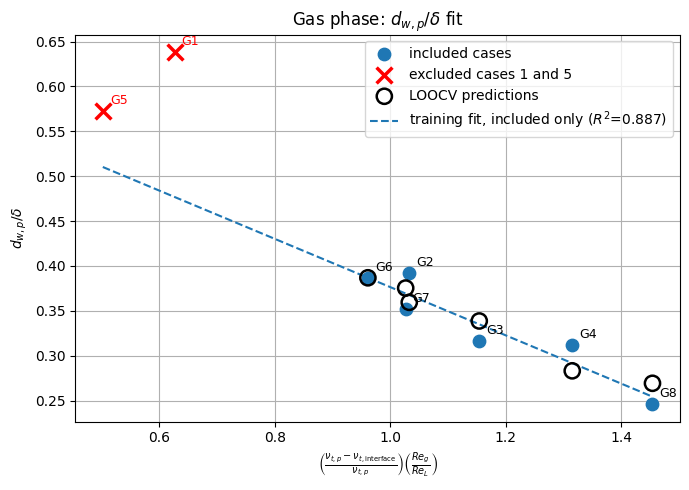

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# Reynolds numbers
# ============================================================

Re_L = np.array([
    3450.3535531, 3604.56651513, 3650.38144777, 3744.77563182,
    4791.70675035, 5137.32386263, 5192.2847177, 5310.30353933
])

Re_g = np.array([
    2444.18629244, 5714.13581516, 6692.97239, 9963.29544459,
    2535.15810329, 5819.1523274, 6813.96014038, 10133.83525732
])

# ============================================================
# Load gas dataset
# ============================================================

GAS_CSV = "/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv"
df_gas = pd.read_csv(GAS_CSV)

# ============================================================
# One row per case
# ============================================================

df_case = (
    df_gas.groupby("case_id", as_index=False)
    .first()[["case_id", "d_wall_p_delta", "nut_interface", "nut_p"]]
)

# case_id is assumed to be 0-based: 0,...,7
df_case["case_number"] = df_case["case_id"] + 1

# add Reynolds numbers
df_case["Re_g"] = df_case["case_id"].map(lambda i: Re_g[int(i)])
df_case["Re_L"] = df_case["case_id"].map(lambda i: Re_L[int(i)])

# ============================================================
# Define x and y
# ============================================================

df_case["xvar"] = (
    (df_case["nut_p"] - df_case["nut_interface"]) / df_case["nut_p"]
) * (
    df_case["Re_g"] / df_case["Re_L"]
)

df_case["yvar"] = df_case["d_wall_p_delta"]

# ============================================================
# Exclude case 1 and case 5 from fitting
# ============================================================

excluded_cases = np.array([1, 5])

included_mask = ~df_case["case_number"].isin(excluded_cases)
excluded_mask = df_case["case_number"].isin(excluded_cases)

df_fit = df_case[included_mask].copy()
df_excluded = df_case[excluded_mask].copy()

x_fit_data = df_fit["xvar"].values
y_fit_data = df_fit["yvar"].values

# ============================================================
# Training fit on included cases only
# y = m*x + b
# ============================================================

m, b = np.polyfit(x_fit_data, y_fit_data, 1)

y_train_pred = m * x_fit_data + b

train_r2 = r2_score(y_fit_data, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_fit_data, y_train_pred))
train_mae = mean_absolute_error(y_fit_data, y_train_pred)

# smooth fit line over the full displayed range
xfit = np.linspace(df_case["xvar"].min(), df_case["xvar"].max(), 200)
yfit = m * xfit + b

# ============================================================
# LOOCV only on included cases
# ============================================================

loocv_pred = np.zeros_like(y_fit_data, dtype=float)
loocv_m = np.zeros_like(y_fit_data, dtype=float)
loocv_b = np.zeros_like(y_fit_data, dtype=float)

for i in range(len(x_fit_data)):
    loo_mask = np.ones(len(x_fit_data), dtype=bool)
    loo_mask[i] = False

    x_train_loo = x_fit_data[loo_mask]
    y_train_loo = y_fit_data[loo_mask]

    m_i, b_i = np.polyfit(x_train_loo, y_train_loo, 1)

    loocv_m[i] = m_i
    loocv_b[i] = b_i
    loocv_pred[i] = m_i * x_fit_data[i] + b_i

loocv_r2 = r2_score(y_fit_data, loocv_pred)
loocv_rmse = np.sqrt(mean_squared_error(y_fit_data, loocv_pred))
loocv_mae = mean_absolute_error(y_fit_data, loocv_pred)

# ============================================================
# Print results
# ============================================================

print("============================================================")
print("Gas phase fit, excluding case 1 and case 5")
print("============================================================")
print()
print("Data table:")
print(df_case[[
    "case_number",
    "case_id",
    "Re_g",
    "Re_L",
    "nut_interface",
    "nut_p",
    "xvar",
    "yvar"
]])
print()
print("Fitted relation:")
print(f"y = {m:.6f} x + {b:.6f}")
print()
print("where:")
print(r"x = ((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)")
print(r"y = d_wall_p_delta")
print()
print("Included cases:")
print(df_fit["case_number"].values)
print()
print("Excluded cases:")
print(df_excluded["case_number"].values)
print()
print("Training metrics on included cases:")
print(f"R²    = {train_r2:.6f}")
print(f"RMSE  = {train_rmse:.6f}")
print(f"MAE   = {train_mae:.6f}")
print()
print("LOOCV metrics on included cases:")
print(f"R²    = {loocv_r2:.6f}")
print(f"RMSE  = {loocv_rmse:.6f}")
print(f"MAE   = {loocv_mae:.6f}")

# ============================================================
# Save summary and LOOCV details
# ============================================================

summary_df = pd.DataFrame({
    "model": ["y = m*x + b"],
    "x_definition": ["((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)"],
    "y_definition": ["d_wall_p_delta"],
    "excluded_cases": [", ".join(map(str, excluded_cases))],
    "included_cases": [", ".join(map(str, df_fit["case_number"].values))],
    "m": [m],
    "b": [b],
    "training_R2": [train_r2],
    "training_RMSE": [train_rmse],
    "training_MAE": [train_mae],
    "LOOCV_R2": [loocv_r2],
    "LOOCV_RMSE": [loocv_rmse],
    "LOOCV_MAE": [loocv_mae]
})

loocv_details_df = df_fit[[
    "case_id",
    "case_number",
    "Re_g",
    "Re_L",
    "d_wall_p_delta",
    "nut_interface",
    "nut_p",
    "xvar",
    "yvar"
]].copy()

loocv_details_df["y_train_fit_pred"] = y_train_pred
loocv_details_df["y_LOOCV_pred"] = loocv_pred
loocv_details_df["LOOCV_error"] = y_fit_data - loocv_pred
loocv_details_df["LOOCV_abs_error"] = np.abs(y_fit_data - loocv_pred)
loocv_details_df["LOOCV_m"] = loocv_m
loocv_details_df["LOOCV_b"] = loocv_b

summary_path = "/content/drive/MyDrive/gas_phase_dwall_fit_summary.csv"
loocv_path = "/content/drive/MyDrive/gas_phase_dwall_LOOCV_details.csv"

summary_df.to_csv(summary_path, index=False)
loocv_details_df.to_csv(loocv_path, index=False)

print()
print("Saved files:")
print(summary_path)
print(loocv_path)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

# included cases
plt.scatter(
    df_fit["xvar"],
    df_fit["yvar"],
    s=80,
    label="included cases",
    zorder=3
)

# excluded cases: red crosses
plt.scatter(
    df_excluded["xvar"],
    df_excluded["yvar"],
    s=130,
    marker="x",
    color="red",
    linewidths=2.5,
    label="excluded cases 1 and 5",
    zorder=4
)

# LOOCV predictions: hollow black circles
plt.scatter(
    df_fit["xvar"],
    loocv_pred,
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    label="LOOCV predictions",
    zorder=5
)

# final training fit
plt.plot(
    xfit,
    yfit,
    "--",
    label=fr"training fit, included only ($R^2$={train_r2:.3f})",
    zorder=2
)

# labels for included cases
for _, row in df_fit.iterrows():
    plt.annotate(
        f"G{int(row['case_number'])}",
        (row["xvar"], row["yvar"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

# labels for excluded cases
for _, row in df_excluded.iterrows():
    plt.annotate(
        f"G{int(row['case_number'])}",
        (row["xvar"], row["yvar"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
        color="red"
    )

plt.xlabel(
    r"$\left(\frac{\nu_{t,p}-\nu_{t,\mathrm{interface}}}{\nu_{t,p}}\right)"
    r"\left(\frac{Re_g}{Re_L}\right)$"
)
plt.ylabel(r"$d_{w,p}/\delta$")
plt.title(
    r"Gas phase: $d_{w,p}/\delta$ fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

x values:
G1: 0.626590
G2: 1.033070
G3: 1.154375
G4: 1.315463
G5: 0.502136
G6: 0.961423
G7: 1.026896
G8: 1.454503

Gas phase C_{1,g} fit
Excluded cases: [1, 5]
C_{1,g} = 2.313850 * x + -3.359563

where:
x = ((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)

Included cases:
[2 3 4 6 7 8]

Excluded cases:
[1 5]

Training metrics on included cases:
R²    = 0.837073
RMSE  = 0.178843
MAE   = 0.131017

LOOCV metrics on included cases:
R²    = 0.708971
RMSE  = 0.239025
MAE   = 0.176841

Saved files:
/content/drive/MyDrive/gas_phase_C1_g_fit_summary.csv
/content/drive/MyDrive/gas_phase_C1_g_LOOCV_details.csv


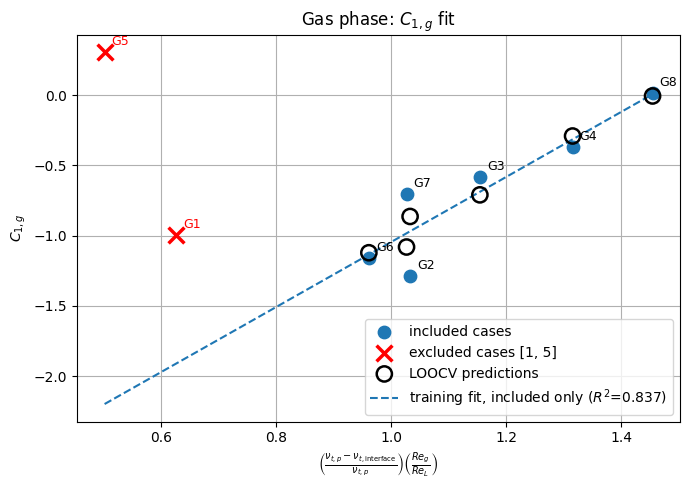


Gas phase C_{2,g} fit
Excluded cases: [1, 5, 8]
C_{2,g} = 12.055194 * x + -6.164560

where:
x = ((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)

Included cases:
[2 3 4 6 7]

Excluded cases:
[1 5 8]

Training metrics on included cases:
R²    = 0.867693
RMSE  = 0.589434
MAE   = 0.448279

LOOCV metrics on included cases:
R²    = 0.722530
RMSE  = 0.853595
MAE   = 0.715789

Saved files:
/content/drive/MyDrive/gas_phase_C2_g_fit_summary.csv
/content/drive/MyDrive/gas_phase_C2_g_LOOCV_details.csv


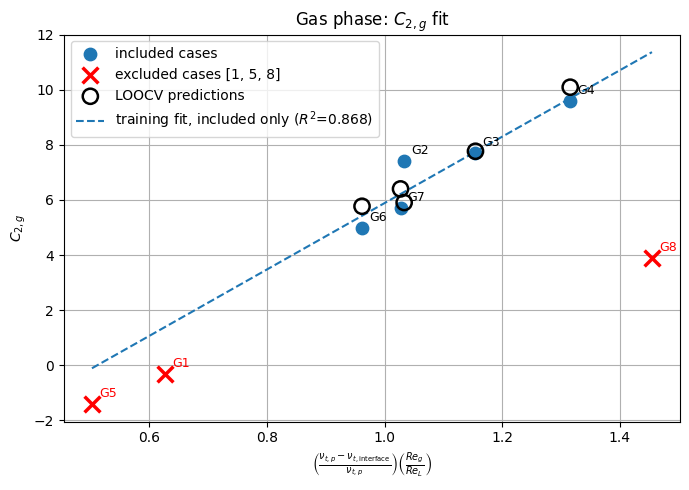

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================================
# Reynolds numbers
# ============================================================

Re_L = np.array([
    3450.3535531, 3604.56651513, 3650.38144777, 3744.77563182,
    4791.70675035, 5137.32386263, 5192.2847177, 5310.30353933
])

Re_g = np.array([
    2444.18629244, 5714.13581516, 6692.97239, 9963.29544459,
    2535.15810329, 5819.1523274, 6813.96014038, 10133.83525732
])

# ============================================================
# Gas fitted parameters from your table
# ============================================================

C1 = np.array([
    -0.997, -1.284, -0.581, -0.372,
     0.305, -1.157, -0.705,  0.013
])

C2 = np.array([
    -0.325, 7.410, 7.695, 9.594,
    -1.410, 4.982, 5.694, 3.885
])

case_labels = np.arange(1, 9)

# ============================================================
# Load gas dataset
# ============================================================

GAS_CSV = "/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv"
df_gas = pd.read_csv(GAS_CSV)

df_case = (
    df_gas.groupby("case_id", as_index=False)
    .first()[["case_id", "nut_interface", "nut_p"]]
    .sort_values("case_id")
)

# case_id is assumed to be 0-based: 0,...,7
df_case["case_number"] = df_case["case_id"] + 1

nut_interface = df_case["nut_interface"].values
nut_p = df_case["nut_p"].values

# ============================================================
# x-axis:
# ((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)
# ============================================================

x = ((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)

df_case["Re_g"] = Re_g
df_case["Re_L"] = Re_L
df_case["xvar"] = x
df_case["C1"] = C1
df_case["C2"] = C2

print("x values:")
for i in range(len(x)):
    print(f"G{case_labels[i]}: {x[i]:.6f}")

# ============================================================
# Helper: fit + LOOCV + metrics + saving + plotting
# ============================================================

def fit_plot_loocv(
    x_all,
    y_all,
    y_name,
    ylabel_latex,
    output_prefix,
    excluded_cases
):
    excluded_cases = np.array(excluded_cases)

    included_mask = ~np.isin(case_labels, excluded_cases)
    excluded_mask = np.isin(case_labels, excluded_cases)

    # ----------------------------
    # Split included/excluded cases
    # ----------------------------

    x_fit = x_all[included_mask]
    y_fit = y_all[included_mask]
    cases_fit = case_labels[included_mask]

    x_excl = x_all[excluded_mask]
    y_excl = y_all[excluded_mask]
    cases_excl = case_labels[excluded_mask]

    # ----------------------------
    # Final training fit
    # ----------------------------

    m, b = np.polyfit(x_fit, y_fit, 1)
    y_train_pred = m * x_fit + b

    train_r2 = r2_score(y_fit, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_fit, y_train_pred))
    train_mae = mean_absolute_error(y_fit, y_train_pred)

    # ----------------------------
    # LOOCV only on included cases
    # ----------------------------

    loocv_pred = np.zeros_like(y_fit, dtype=float)
    loocv_m = np.zeros_like(y_fit, dtype=float)
    loocv_b = np.zeros_like(y_fit, dtype=float)

    for i in range(len(x_fit)):
        loo_mask = np.ones(len(x_fit), dtype=bool)
        loo_mask[i] = False

        x_train_loo = x_fit[loo_mask]
        y_train_loo = y_fit[loo_mask]

        m_i, b_i = np.polyfit(x_train_loo, y_train_loo, 1)

        loocv_m[i] = m_i
        loocv_b[i] = b_i
        loocv_pred[i] = m_i * x_fit[i] + b_i

    loocv_r2 = r2_score(y_fit, loocv_pred)
    loocv_rmse = np.sqrt(mean_squared_error(y_fit, loocv_pred))
    loocv_mae = mean_absolute_error(y_fit, loocv_pred)

    # ----------------------------
    # Print results
    # ----------------------------

    print()
    print("============================================================")
    print(f"Gas phase {y_name} fit")
    print("============================================================")
    print(f"Excluded cases: {excluded_cases.tolist()}")
    print(f"{y_name} = {m:.6f} * x + {b:.6f}")
    print()
    print("where:")
    print("x = ((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)")
    print()
    print("Included cases:")
    print(cases_fit)
    print()
    print("Excluded cases:")
    print(cases_excl)
    print()
    print("Training metrics on included cases:")
    print(f"R²    = {train_r2:.6f}")
    print(f"RMSE  = {train_rmse:.6f}")
    print(f"MAE   = {train_mae:.6f}")
    print()
    print("LOOCV metrics on included cases:")
    print(f"R²    = {loocv_r2:.6f}")
    print(f"RMSE  = {loocv_rmse:.6f}")
    print(f"MAE   = {loocv_mae:.6f}")

    # ----------------------------
    # Save summary and LOOCV details
    # ----------------------------

    summary_df = pd.DataFrame({
        "model": [f"{y_name} = m*x + b"],
        "x_definition": ["((nut_p - nut_interface) / nut_p) * (Re_g / Re_L)"],
        "y_definition": [y_name],
        "excluded_cases": [", ".join(map(str, excluded_cases))],
        "included_cases": [", ".join(map(str, cases_fit))],
        "m": [m],
        "b": [b],
        "training_R2": [train_r2],
        "training_RMSE": [train_rmse],
        "training_MAE": [train_mae],
        "LOOCV_R2": [loocv_r2],
        "LOOCV_RMSE": [loocv_rmse],
        "LOOCV_MAE": [loocv_mae]
    })

    loocv_details_df = pd.DataFrame({
        "case_number": cases_fit,
        "case_id": cases_fit - 1,
        "Re_g": Re_g[included_mask],
        "Re_L": Re_L[included_mask],
        "nut_interface": nut_interface[included_mask],
        "nut_p": nut_p[included_mask],
        "xvar": x_fit,
        f"{y_name}_true": y_fit,
        f"{y_name}_train_fit_pred": y_train_pred,
        f"{y_name}_LOOCV_pred": loocv_pred,
        "LOOCV_error": y_fit - loocv_pred,
        "LOOCV_abs_error": np.abs(y_fit - loocv_pred),
        "LOOCV_m": loocv_m,
        "LOOCV_b": loocv_b
    })

    summary_path = f"/content/drive/MyDrive/{output_prefix}_fit_summary.csv"
    loocv_path = f"/content/drive/MyDrive/{output_prefix}_LOOCV_details.csv"

    summary_df.to_csv(summary_path, index=False)
    loocv_details_df.to_csv(loocv_path, index=False)

    print()
    print("Saved files:")
    print(summary_path)
    print(loocv_path)

    # ----------------------------
    # Plot
    # ----------------------------

    xline = np.linspace(x_all.min(), x_all.max(), 200)
    yline = m * xline + b

    plt.figure(figsize=(7, 5))

    # included cases
    plt.scatter(
        x_fit,
        y_fit,
        s=80,
        label="included cases",
        zorder=3
    )

    # excluded cases: red crosses
    plt.scatter(
        x_excl,
        y_excl,
        s=130,
        marker="x",
        color="red",
        linewidths=2.5,
        label=f"excluded cases {excluded_cases.tolist()}",
        zorder=4
    )

    # LOOCV predictions: hollow black circles
    plt.scatter(
        x_fit,
        loocv_pred,
        s=120,
        facecolors="none",
        edgecolors="black",
        linewidths=1.8,
        label="LOOCV predictions",
        zorder=5
    )

    # final fit line
    plt.plot(
        xline,
        yline,
        "--",
        label=fr"training fit, included only ($R^2$={train_r2:.3f})",
        zorder=2
    )

    # labels for all cases
    for i in range(len(x_all)):
        color = "red" if case_labels[i] in excluded_cases else "black"
        plt.annotate(
            f"G{case_labels[i]}",
            (x_all[i], y_all[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
            color=color
        )

    plt.xlabel(
        r"$\left(\frac{\nu_{t,p}-\nu_{t,\mathrm{interface}}}{\nu_{t,p}}\right)"
        r"\left(\frac{Re_g}{Re_L}\right)$"
    )
    plt.ylabel(ylabel_latex)
    plt.title(
        fr"Gas phase: ${y_name}$ fit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary_df, loocv_details_df


# ============================================================
# Fit C1: exclude case 1 and 5
# ============================================================

summary_C1, loocv_C1 = fit_plot_loocv(
    x_all=x,
    y_all=C1,
    y_name="C_{1,g}",          # Removed $ to prevent the double-dollar $$ error
    ylabel_latex=r"$C_{1,g}$", # Keeps standard LaTeX formatting for the axis label
    output_prefix="gas_phase_C1_g",
    excluded_cases=[1, 5]
)

# ============================================================
# Fit C2: exclude case 1, 5, and 8
# ============================================================

summary_C2, loocv_C2 = fit_plot_loocv(
    x_all=x,
    y_all=C2,
    y_name="C_{2,g}",          # Removed $ to prevent the double-dollar $$ error
    ylabel_latex=r"$C_{2,g}$", # Keeps standard LaTeX formatting for the axis label
    output_prefix="gas_phase_C2_g",
    excluded_cases=[1, 5, 8]
)

Fitted model: f_interface = A * Re_g^n
A = 7.74191142
n = -0.61794634
RMSE = 0.00161822
R^2 = 0.98539606


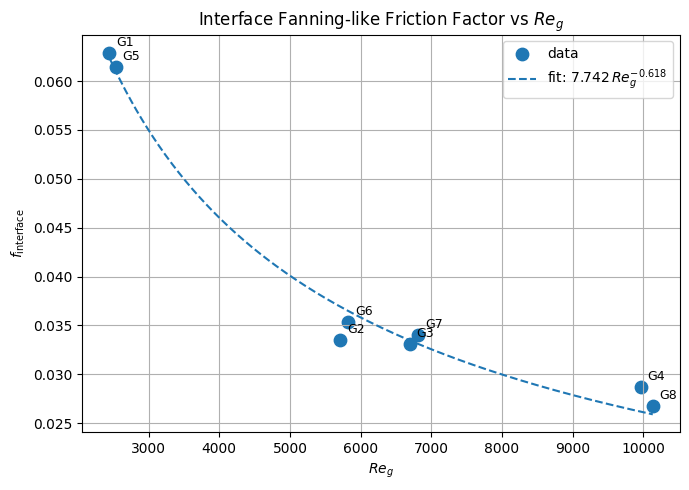

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Given data
# ============================================================
Re_g = np.array([
    2444.18629244, 5714.13581516, 6692.97239, 9963.29544459,
    2535.15810329, 5819.1523274, 6813.96014038, 10133.83525732
])

f_interface = np.array([
    0.062915,
    0.033565,
    0.033090,
    0.028673,
    0.061486,
    0.035361,
    0.034008,
    0.026772
])

case_labels = np.arange(1, 9)

# ============================================================
# Model: A * Re_g^n   with n < 0
# ============================================================
def power_law(x, A, n):
    return A * x**n

# initial guess
A0 = 1.0
n0 = -0.5

# enforce n < 0 and A > 0
popt, pcov = curve_fit(
    power_law,
    Re_g,
    f_interface,
    p0=[A0, n0],
    bounds=([0.0, -np.inf], [np.inf, 0.0])
)

A_fit, n_fit = popt
f_pred = power_law(Re_g, A_fit, n_fit)

# ============================================================
# Metrics
# ============================================================
ss_res = np.sum((f_interface - f_pred)**2)
ss_tot = np.sum((f_interface - np.mean(f_interface))**2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean((f_interface - f_pred)**2))

print(f"Fitted model: f_interface = A * Re_g^n")
print(f"A = {A_fit:.8f}")
print(f"n = {n_fit:.8f}")
print(f"RMSE = {rmse:.8f}")
print(f"R^2 = {r2:.8f}")

# ============================================================
# Smooth curve for plotting
# ============================================================
xfit = np.linspace(Re_g.min(), Re_g.max(), 400)
yfit = power_law(xfit, A_fit, n_fit)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(7, 5))
plt.scatter(Re_g, f_interface, s=80, label='data')
plt.plot(xfit, yfit, '--', label=fr'fit: ${A_fit:.3f}\,Re_g^{{{n_fit:.3f}}}$')

for i in range(len(Re_g)):
    plt.annotate(
        f"G{case_labels[i]}",
        (Re_g[i], f_interface[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

plt.xlabel(r'$Re_g$')
plt.ylabel(r'$f_{\mathrm{interface}}$')
plt.title(r'Interface Fanning-like Friction Factor vs $Re_g$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


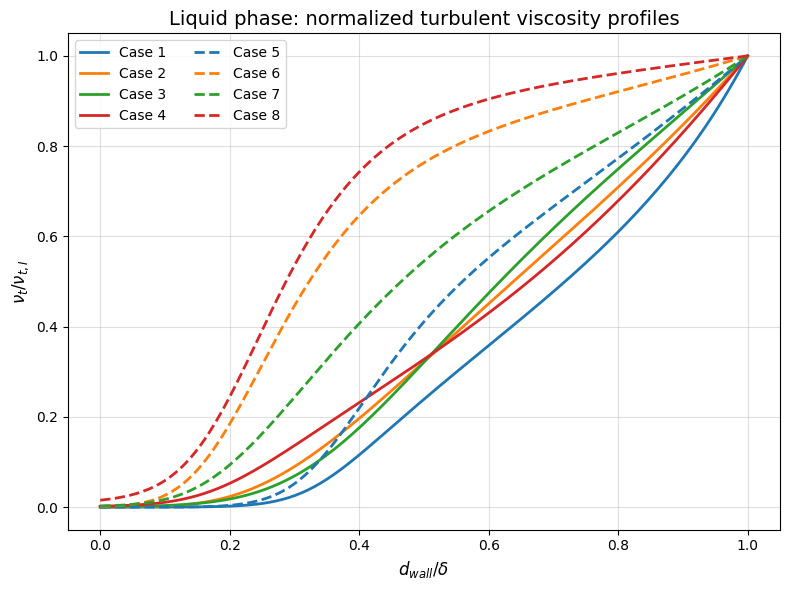

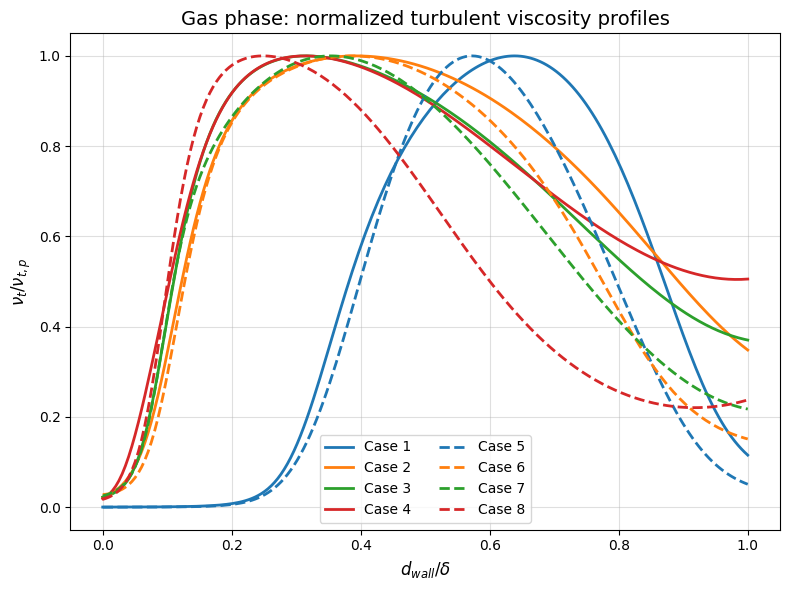

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount('/content/drive')

# ============================================================
# Load datasets
# ============================================================

LIQUID_CSV = '/content/drive/MyDrive/liquid_dataset_geometry_nut_norm.csv'
GAS_CSV    = '/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv'

df_liquid = pd.read_csv(LIQUID_CSV)
df_gas    = pd.read_csv(GAS_CSV)

# ============================================================
# Helper plotting function
# ============================================================

def plot_all_cases_paired_style(
    df,
    x_col='d_wall_delta',
    y_col='nut_over_nut_p',
    case_col='case_id',
    title='',
    ylabel=r'$\nu_t / \nu_{t,p}$'
):
    plt.figure(figsize=(8, 6))

    # Same color for cases:
    # 1 and 5, 2 and 6, 3 and 7, 4 and 8
    colors = {
        0: 'C0',  # case 1
        1: 'C1',  # case 2
        2: 'C2',  # case 3
        3: 'C3',  # case 4
        4: 'C0',  # case 5
        5: 'C1',  # case 6
        6: 'C2',  # case 7
        7: 'C3',  # case 8
    }

    linestyles = {
        0: '-',   # case 1
        1: '-',   # case 2
        2: '-',   # case 3
        3: '-',   # case 4
        4: '--',  # case 5
        5: '--',  # case 6
        6: '--',  # case 7
        7: '--',  # case 8
    }

    case_ids = sorted(df[case_col].unique())

    for case_id in case_ids:
        dfc = df[df[case_col] == case_id].copy()

        x = dfc[x_col].values
        y = dfc[y_col].values

        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if len(x) == 0:
            continue

        idx = np.argsort(x)
        x = x[idx]
        y = y[idx]

        plt.plot(
            x,
            y,
            linestyle=linestyles.get(case_id, '-'),
            color=colors.get(case_id, None),
            linewidth=2,
            label=f'Case {case_id + 1}'
        )

    plt.xlabel(r'$d_{wall}/\delta$', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.4)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

# ============================================================
# Liquid plot
# ============================================================

plot_all_cases_paired_style(
    df=df_liquid,
    x_col='d_wall_delta',
    y_col='nut_over_nut_p',
    case_col='case_id',
    title='Liquid phase: normalized turbulent viscosity profiles',
    ylabel=r'$\nu_{t}/\nu_{t,I}$'
)

# ============================================================
# Gas plot
# ============================================================

plot_all_cases_paired_style(
    df=df_gas,
    x_col='d_wall_delta',
    y_col='nut_over_nut_p',
    case_col='case_id',
    title='Gas phase: normalized turbulent viscosity profiles',
    ylabel=r'$\nu_{t}/\nu_{t,p}$'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Liquid columns:
Index(['case_id', 'Y', 'Y_p', 'delta', 'd_wall_delta', 'd_interface_delta',
       'd_wall_p_delta', 'd_interface_p_delta', 'nut_interface', 'nut_p',
       'nut', 'nut_over_nut_p', 'case_number', 'Re_L', 'Re_g', 'Re_ratio'],
      dtype='object')

Gas columns:
Index(['case_id', 'Y', 'Y_p', 'delta', 'd_wall_delta', 'd_interface_delta',
       'd_wall_p_delta', 'd_interface_p_delta', 'nut_interface', 'nut_p',
       'nut', 'nut_over_nut_p', 'case_number', 'Re_L', 'Re_g', 'Re_ratio'],
      dtype='object')

Using columns:
Liquid x column: d_wall_delta
Liquid y column: nut_over_nut_p
Gas x column:    d_wall_delta
Gas y column:    nut_over_nut_p


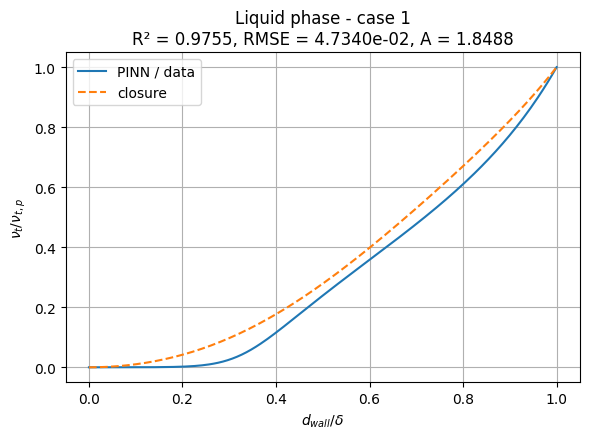

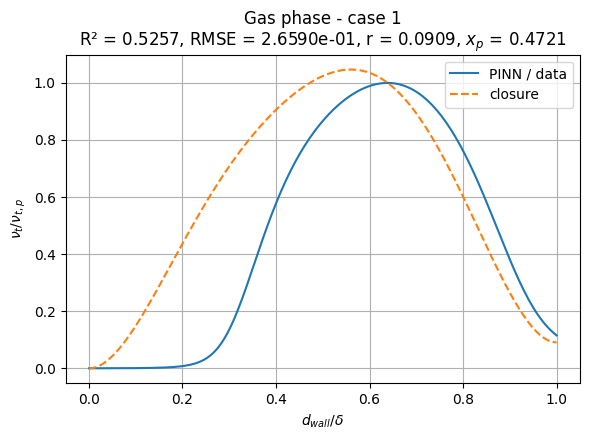

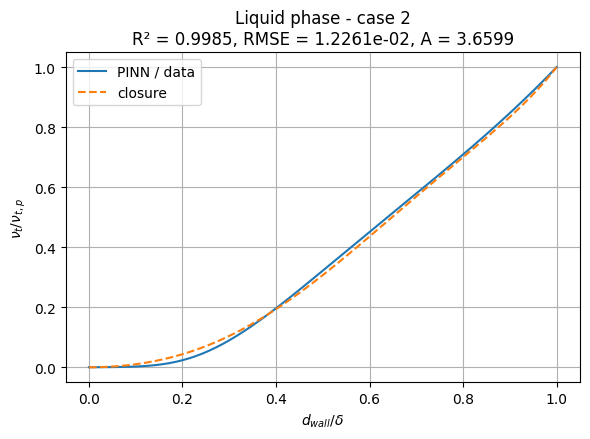

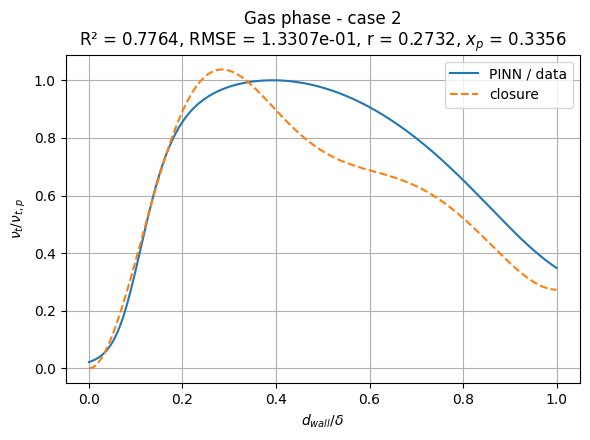

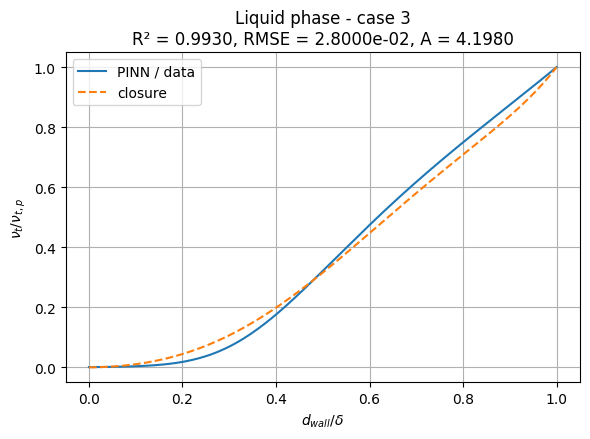

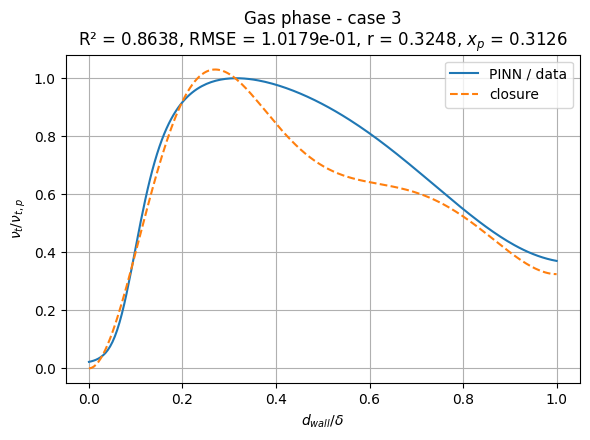

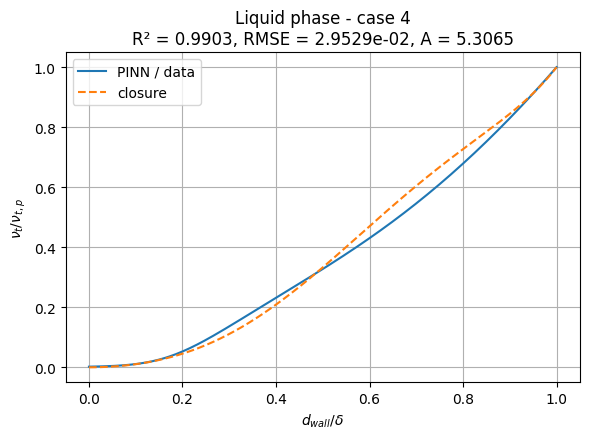

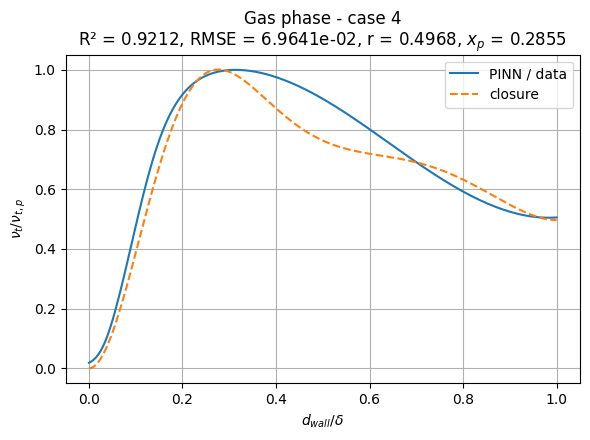

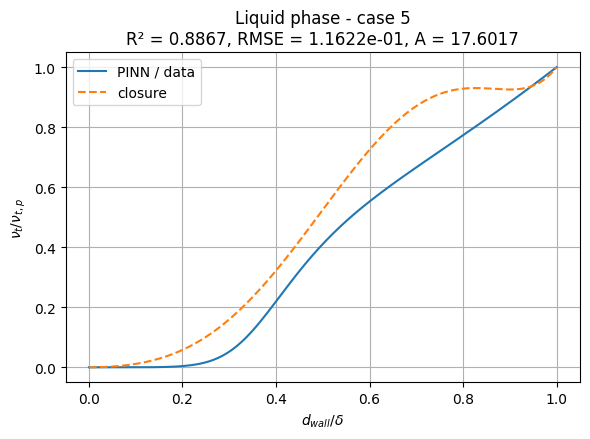

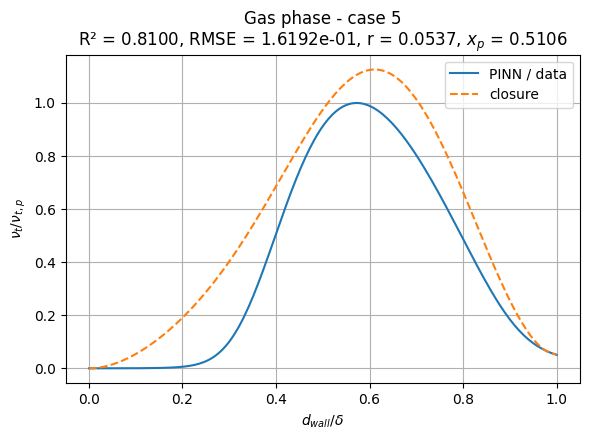

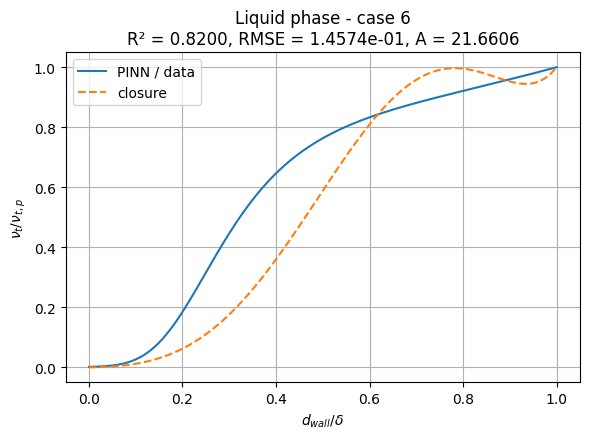

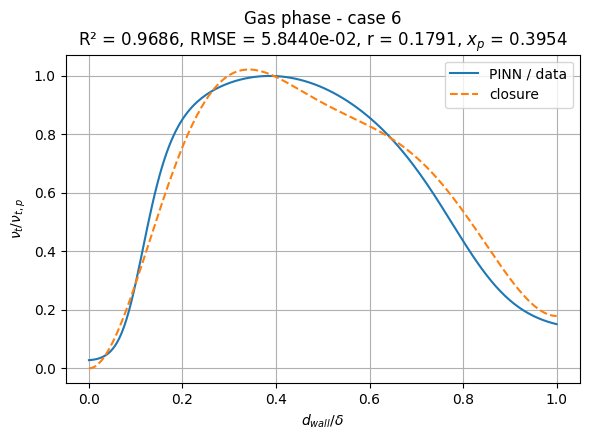

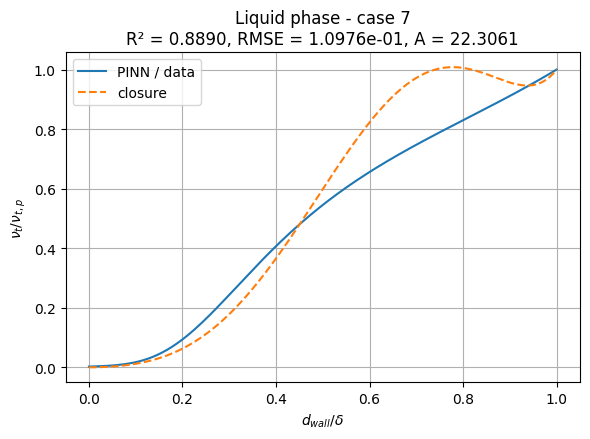

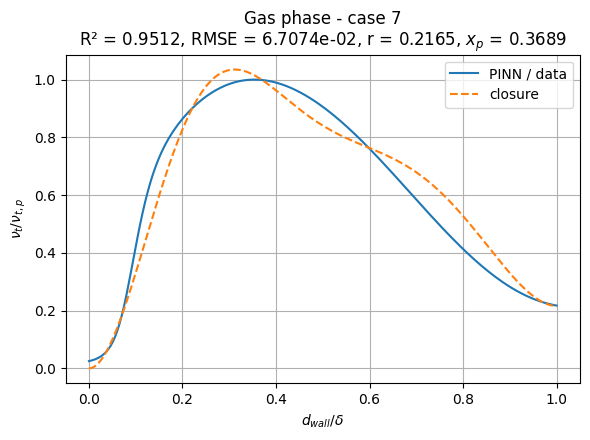

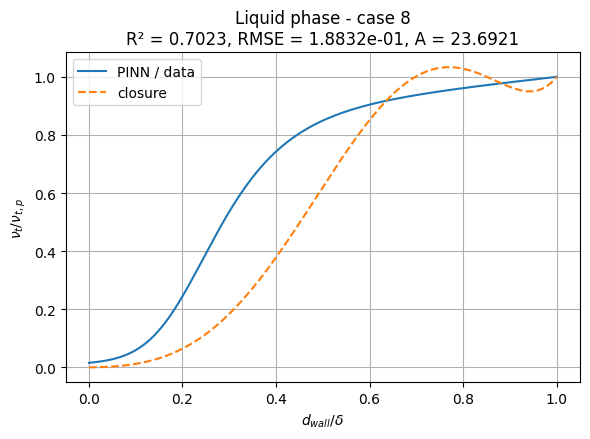

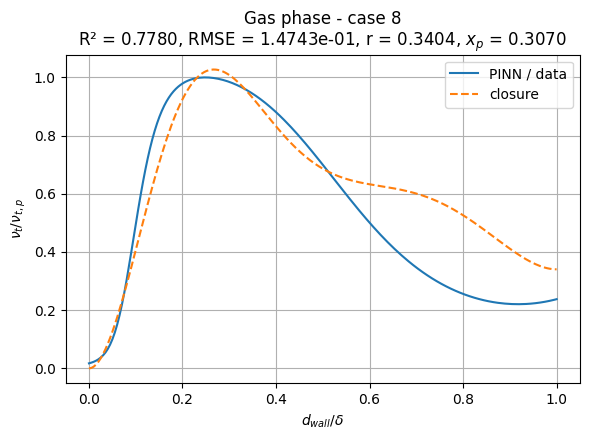


Closure performance summary:
     phase  case_id  case_number         Re_L          Re_g          A  \
0   liquid        0            1  3450.353553   2444.186292   1.848842   
1      gas        0            1  3450.353553   2444.186292        NaN   
2   liquid        1            2  3604.566515   5714.135815   3.659919   
3      gas        1            2  3604.566515   5714.135815        NaN   
4   liquid        2            3  3650.381448   6692.972390   4.197970   
5      gas        2            3  3650.381448   6692.972390        NaN   
6   liquid        3            4  3744.775632   9963.295445   5.306535   
7      gas        3            4  3744.775632   9963.295445        NaN   
8   liquid        4            5  4791.706750   2535.158103  17.601694   
9      gas        4            5  4791.706750   2535.158103        NaN   
10  liquid        5            6  5137.323863   5819.152327  21.660621   
11     gas        5            6  5137.323863   5819.152327        NaN   
12  liqu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUT PATHS
# ============================================================

LIQUID_CSV = "/content/drive/MyDrive/liquid_dataset_geometry_nut_norm.csv"
GAS_CSV    = "/content/drive/MyDrive/gas_dataset_geometry_nut_norm.csv"

OUT_CSV = "/content/drive/MyDrive/liquid_gas_closure_metrics.csv"

# ============================================================
# FLOW DATA
# case_id is assumed to be 0,1,...,7
# case_number is 1,2,...,8
# ============================================================

Re_L = np.array([
    3450.3535531, 3604.56651513, 3650.38144777, 3744.77563182,
    4791.70675035, 5137.32386263, 5192.2847177, 5310.30353933
])

Re_g = np.array([
    2444.18629244, 5714.13581516, 6692.97239, 9963.29544459,
    2535.15810329, 5819.1523274, 6813.96014038, 10133.83525732
])

flow_df = pd.DataFrame({
    "case_id": np.arange(8),
    "case_number": np.arange(1, 9),
    "Re_L": Re_L,
    "Re_g": Re_g,
    "Re_ratio": Re_g / Re_L
})

# ============================================================
# COLUMN HELPERS
# ============================================================

def find_column(df, candidates, df_name="dataset"):
    """
    Finds the first available column from a list of possible column names.
    """
    for c in candidates:
        if c in df.columns:
            return c

    raise KeyError(
        f"None of these columns were found in {df_name}: {candidates}\n\n"
        f"Available columns are:\n{list(df.columns)}"
    )


def attach_flow_data(df, phase_name):
    """
    Attaches Re_L and Re_g to the dataset.
    Handles both possible case_id conventions:
    - case_id = 0,...,7
    - case_id = 1,...,8
    """

    df = df.copy()

    if "case_id" not in df.columns:
        raise KeyError(f"'case_id' column not found in {phase_name} dataset.")

    case_ids = sorted(df["case_id"].dropna().unique())

    # If case_id is 1,...,8, convert internally to 0,...,7
    if min(case_ids) == 1 and max(case_ids) == 8:
        df["case_id_original"] = df["case_id"]
        df["case_id"] = df["case_id"] - 1

    df = df.merge(flow_df, on="case_id", how="left")

    if df["Re_L"].isna().any() or df["Re_g"].isna().any():
        raise ValueError(
            f"Some cases in {phase_name} dataset could not be matched with Re data.\n"
            f"Check your case_id values."
        )

    return df


def metrics(y_true, y_pred):
    """
    Computes RMSE and R2.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return np.nan, np.nan

    rmse = np.sqrt(np.mean((y_true - y_pred)**2))

    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return rmse, r2


# ============================================================
# CLOSURE MODELS
# ============================================================

def liquid_closure(x, Re_L):
    """
    Liquid closure:

        nut / nut_interface = x^2 [1 + A (x(1-x))^2]

    where:
        x = d_wall / delta
        A = 0.011744 Re_L - 38.672110

    If your liquid dataset uses nut_over_nut_p, this is still valid only
    when nut_p = nut_interface for the liquid phase.
    """

    A = 0.011744 * Re_L - 38.672110

    eta = x * (1.0 - x)

    y = x**2 * (1.0 + A * eta**2)

    return y, A


def gas_parameters(Re_L, Re_g):
    """
    Gas closure parameters from your equations.
    """

    Re_ratio = Re_g / Re_L

    # r = nut_interface / nut_peak
    r = 0.207886 * Re_ratio - 0.056330

    # X = ((nut_peak - nut_interface) / nut_peak) * (Re_g / Re_L)
    #   = (1 - r) * Re_ratio
    X = (1.0 - r) * Re_ratio

    x_peak = -0.268621 * X + 0.645132

    C1 = 2.313850 * X - 3.359563
    C2 = 12.055194 * X - 6.164560

    return r, x_peak, C1, C2, X


def gas_closure(x, Re_L, Re_g):
    """
    Gas closure:

        nut / nut_peak = (1-alpha) b_wall + alpha b_interface

    with:
        x = d_wall / delta
        xp = d_wall_peak / delta
        r = nut_interface / nut_peak

    Written with delta = 1 because x is already normalized.
    """

    r, xp, C1, C2, X = gas_parameters(Re_L, Re_g)

    eps = 1e-12

    # Avoid division by zero if xp becomes too close to 0 or 1
    xp_safe = np.clip(xp, eps, 1.0 - eps)

    # alpha
    alpha = x**2 / (
        x**2 + xp_safe**2 * ((1.0 - x) / (1.0 - xp_safe))**2 + eps
    )

    # b_wall
    b_wall = (x / xp_safe)**2 * (
        1.0 + C1 * (x * (xp_safe - x)) / (xp_safe**2 + eps)
    )

    # b_interface
    b_interface = r + (1.0 - r) * ((1.0 - x) / (1.0 - xp_safe))**2 * (
        1.0 + C2 * ((xp_safe - x) * (1.0 - x)) / ((1.0 - xp_safe)**2 + eps)
    )

    y = (1.0 - alpha) * b_wall + alpha * b_interface

    return y, r, xp, C1, C2, X


# ============================================================
# LOAD DATASETS
# ============================================================

df_liquid = pd.read_csv(LIQUID_CSV)
df_gas = pd.read_csv(GAS_CSV)

df_liquid = attach_flow_data(df_liquid, "liquid")
df_gas = attach_flow_data(df_gas, "gas")

print("Liquid columns:")
print(df_liquid.columns)

print("\nGas columns:")
print(df_gas.columns)

# ============================================================
# DETECT IMPORTANT COLUMNS
# ============================================================

x_col_liq = find_column(
    df_liquid,
    ["d_wall_delta", "d_wall_over_delta", "x", "s"],
    "liquid"
)

y_col_liq = find_column(
    df_liquid,
    ["nut_over_nut_p", "nut_over_nut_peak", "nut_norm", "nu_t_over_nu_t_peak"],
    "liquid"
)

x_col_gas = find_column(
    df_gas,
    ["d_wall_delta", "d_wall_over_delta", "x", "s"],
    "gas"
)

y_col_gas = find_column(
    df_gas,
    ["nut_over_nut_p", "nut_over_nut_peak", "nut_norm", "nu_t_over_nu_t_peak"],
    "gas"
)

print("\nUsing columns:")
print(f"Liquid x column: {x_col_liq}")
print(f"Liquid y column: {y_col_liq}")
print(f"Gas x column:    {x_col_gas}")
print(f"Gas y column:    {y_col_gas}")


# ============================================================
# MAIN LOOP: LIQUID + GAS PLOTS AND METRICS
# ============================================================

summary_rows = []

for case_id in range(8):

    case_number = case_id + 1

    # --------------------------------------------------------
    # Liquid phase
    # --------------------------------------------------------
    dfc = df_liquid[df_liquid["case_id"] == case_id].copy()

    if len(dfc) > 0:

        x = dfc[x_col_liq].to_numpy(dtype=float)
        y_true = dfc[y_col_liq].to_numpy(dtype=float)

        ReL_case = dfc["Re_L"].iloc[0]

        y_pred, A = liquid_closure(x, ReL_case)

        mask = np.isfinite(x) & np.isfinite(y_true) & np.isfinite(y_pred)
        x_plot = x[mask]
        y_true_plot = y_true[mask]
        y_pred_plot = y_pred[mask]

        idx = np.argsort(x_plot)
        x_plot = x_plot[idx]
        y_true_plot = y_true_plot[idx]
        y_pred_plot = y_pred_plot[idx]

        rmse, r2 = metrics(y_true_plot, y_pred_plot)

        summary_rows.append({
            "phase": "liquid",
            "case_id": case_id,
            "case_number": case_number,
            "Re_L": Re_L[case_id],
            "Re_g": Re_g[case_id],
            "A": A,
            "r_interface_peak": np.nan,
            "d_wall_peak_delta": np.nan,
            "C1": np.nan,
            "C2": np.nan,
            "X": np.nan,
            "RMSE": rmse,
            "R2": r2,
            "n_points": len(y_true_plot)
        })

        plt.figure(figsize=(6, 4.5))
        plt.plot(x_plot, y_true_plot, label="PINN / data")
        plt.plot(x_plot, y_pred_plot, "--", label="closure")
        plt.xlabel(r"$d_{wall}/\delta$")
        plt.ylabel(r"$\nu_t/\nu_{t,p}$")
        plt.title(
            f"Liquid phase - case {case_number}\n"
            f"R² = {r2:.4f}, RMSE = {rmse:.4e}, A = {A:.4f}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        print(f"Liquid case {case_number}: no data found.")

    # --------------------------------------------------------
    # Gas phase
    # --------------------------------------------------------
    dfc = df_gas[df_gas["case_id"] == case_id].copy()

    if len(dfc) > 0:

        x = dfc[x_col_gas].to_numpy(dtype=float)
        y_true = dfc[y_col_gas].to_numpy(dtype=float)

        ReL_case = dfc["Re_L"].iloc[0]
        ReG_case = dfc["Re_g"].iloc[0]

        y_pred, r, xp, C1, C2, X = gas_closure(x, ReL_case, ReG_case)

        mask = np.isfinite(x) & np.isfinite(y_true) & np.isfinite(y_pred)
        x_plot = x[mask]
        y_true_plot = y_true[mask]
        y_pred_plot = y_pred[mask]

        idx = np.argsort(x_plot)
        x_plot = x_plot[idx]
        y_true_plot = y_true_plot[idx]
        y_pred_plot = y_pred_plot[idx]

        rmse, r2 = metrics(y_true_plot, y_pred_plot)

        summary_rows.append({
            "phase": "gas",
            "case_id": case_id,
            "case_number": case_number,
            "Re_L": Re_L[case_id],
            "Re_g": Re_g[case_id],
            "A": np.nan,
            "r_interface_peak": r,
            "d_wall_peak_delta": xp,
            "C1": C1,
            "C2": C2,
            "X": X,
            "RMSE": rmse,
            "R2": r2,
            "n_points": len(y_true_plot)
        })

        plt.figure(figsize=(6, 4.5))
        plt.plot(x_plot, y_true_plot, label="PINN / data")
        plt.plot(x_plot, y_pred_plot, "--", label="closure")
        plt.xlabel(r"$d_{wall}/\delta$")
        plt.ylabel(r"$\nu_t/\nu_{t,p}$")
        plt.title(
            f"Gas phase - case {case_number}\n"
            f"R² = {r2:.4f}, RMSE = {rmse:.4e}, "
            f"r = {r:.4f}, $x_p$ = {xp:.4f}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        print(f"Gas case {case_number}: no data found.")


# ============================================================
# SAVE SUMMARY TABLE
# ============================================================

df_metrics = pd.DataFrame(summary_rows)

print("\nClosure performance summary:")
print(df_metrics)

df_metrics.to_csv(OUT_CSV, index=False)
print(f"\nSaved metrics to:\n{OUT_CSV}")